#  GAN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
* https://www.kaggle.com/datasets/splcher/animefacedataset
* https://github.com/eriklindernoren/PyTorch-GAN

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении GAN.

In [1]:
import torch as th
import torch.nn as nn

In [2]:
noise = th.randn(1, 100, 1, 1)

In [3]:
generator = nn.Sequential(
    nn.ConvTranspose2d(
        in_channels=100,
        out_channels=8,
        kernel_size=4,
        stride=2,
        padding=1
    ),
    nn.ReLU(),
    nn.ConvTranspose2d(
        in_channels=8,
        out_channels=3,
        kernel_size=4,
        stride=2,
        padding=1
    ),
    nn.ReLU(),
)

In [4]:
img_gen = generator(noise)
img_gen.shape

torch.Size([1, 3, 4, 4])

In [5]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 8, 3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32, 2)
)
discriminator(img_gen)

tensor([[-0.0115, -0.0930]], grad_fn=<AddmmBackward0>)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте набор данных на основе архива `anime.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений.

- [ ] Проверено на семинаре

In [15]:
from zipfile import ZipFile

zipfile = ZipFile("/content/drive/MyDrive/пм21_финашка/3 курс/Deep learning/06_cv/anime.zip", "r")
zipfile.extractall("/content/anime")

In [16]:
import torchvision.transforms.v2 as T
from PIL import Image

from torchvision.datasets import ImageFolder

In [17]:
names = zipfile.namelist()

In [18]:
transform = T.Compose(
        [
      T.Resize((250, 250)),
      T.ToTensor(),
      T.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),   # нормализация данных
    ]
)


/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:43: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


In [19]:
ds = ImageFolder('/content/anime',transform=transform)
ds

Dataset ImageFolder
    Number of datapoints: 63565
    Root location: /content/anime
    StandardTransform
Transform: Compose(
                 Resize(size=[250, 250], interpolation=InterpolationMode.BILINEAR, antialias=warn)
                 ToTensor()
                 Normalize(mean=[0, 0, 0], std=[1, 1, 1], inplace=False)
           )

In [20]:
ds[0]

(tensor([[[0.8392, 0.8392, 0.8392,  ..., 0.9882, 0.9882, 0.9882],
          [0.8392, 0.8392, 0.8392,  ..., 0.9882, 0.9882, 0.9882],
          [0.8510, 0.8510, 0.8510,  ..., 0.9882, 0.9882, 0.9882],
          ...,
          [0.4784, 0.4784, 0.4706,  ..., 0.2000, 0.1804, 0.1804],
          [0.4784, 0.4784, 0.4706,  ..., 0.1961, 0.1765, 0.1765],
          [0.4784, 0.4784, 0.4706,  ..., 0.1961, 0.1765, 0.1765]],
 
         [[0.8275, 0.8275, 0.8275,  ..., 0.8784, 0.8784, 0.8784],
          [0.8275, 0.8275, 0.8275,  ..., 0.8784, 0.8784, 0.8784],
          [0.8392, 0.8392, 0.8392,  ..., 0.8784, 0.8824, 0.8824],
          ...,
          [0.4235, 0.4235, 0.4196,  ..., 0.1569, 0.1373, 0.1373],
          [0.4235, 0.4235, 0.4196,  ..., 0.1529, 0.1333, 0.1333],
          [0.4235, 0.4235, 0.4196,  ..., 0.1529, 0.1333, 0.1333]],
 
         [[0.8078, 0.8078, 0.8078,  ..., 0.8667, 0.8667, 0.8667],
          [0.8078, 0.8078, 0.8078,  ..., 0.8667, 0.8667, 0.8667],
          [0.8157, 0.8157, 0.8196,  ...,

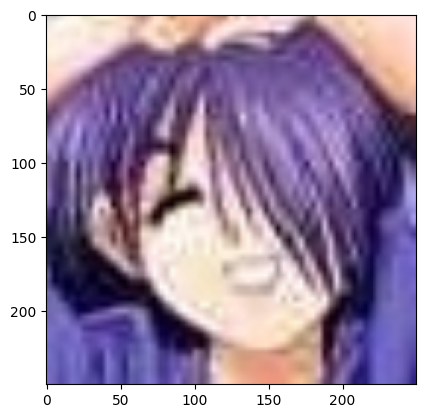

In [22]:
import matplotlib.pyplot as plt

plt.imshow(ds[0][0].permute(1,2,0))

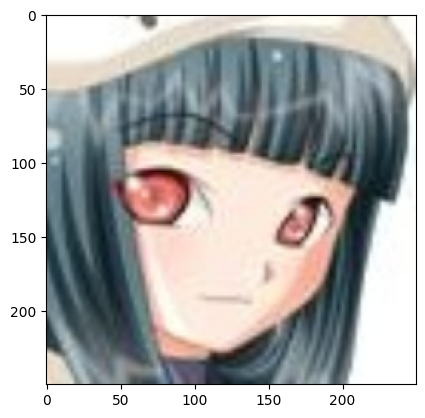

In [23]:
plt.imshow(ds[10][0].permute(1,2,0))

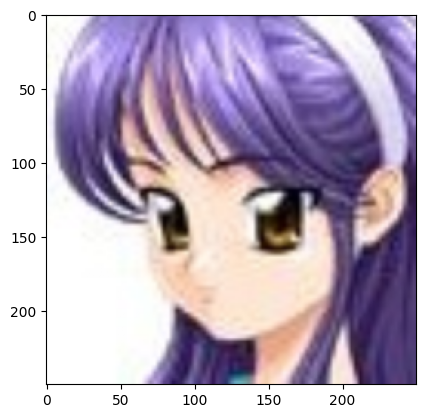

In [24]:
plt.imshow(ds[40][0].permute(1,2,0))

<p class="task" id="2"></p>

2\. Реализуйте архитектуру `DCGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры генерации изображений из случайного шума и сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

<p class="task" id="3"></p>

3\. Создайте наборы данных на основе архива `summer2winter_yosemite.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений, расположив изображения из одной пары рядом по горизонтали.

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Реализуйте архитектуру `CycleGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры преобразования (в обе стороны) и  сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

## Обратная связь
- [ ] Хочу получить обратную связь по решению